## Aparcamiento autónomo asistido mediante Aprendizaje por Refuerzo en un entorno continuo de Gymnasium

El agente será un vehículo que se mueve en un espacio 2D continuo. Debe aparcar en una plaza evitando colisiones con paredes y obstáculos, usando sensores de distancia simulados.

Algoritmos utilizados en principio:
- SARSA
- Q-learning
- DQN

El entorno principal será continuo, porque el problema de vehículo/aparcamiento tiene sentido como problema de control continuo. Pero para Q-Learning y SARSA necesitaremos una versión discretizada del estado.

ContinuousParkingEnv -> observación continua para DQN -> función de discretización para Q-Learning y SARSA

1) creación entorno 

ContinuousParkingEnv 

el entorno tendrá: 


Estado interno continuo: Diseño del MDP


st​=(xt​,yt​,θt​,vt​)
- x_t      = posición horizontal del coche
- y_t      = posición vertical del coche
- theta_t  = orientación del coche en radianes
- v_t      = velocidad actual

Observación continua (vector numérico):


- sensores + distancia a plaza + error angular + velocidad

In [ ]:
obs = [
    x_norm,
    y_norm,
    cos(theta),
    sin(theta),
    v_norm,
    sensor_front,
    sensor_front_left,
    sensor_front_right,
    sensor_left,
    sensor_right,
    sensor_back,
    sensor_back_left,
    sensor_back_right,
    distance_to_goal_norm,
    cos(angle_to_goal),
    sin(angle_to_goal),
    cos(orientation_error),
    sin(orientation_error),
]

Acciones discretas: (aunque el coche real tendria acciones continuas lo vamos a simular)
- avanzar, girar, retroceder, frenar

Algoritmos:
- Q-Learning y SARSA usan observación discretizada
- DQN usa observación continua

Dinámica del vehículo:
- Usamos una dinámica continua sencilla tal que cada acción define una velocidad y un giro 

In [ ]:
x(t+1) = x(t) + vcos(θt​)Δt
y(t+1) = y(t) + vsin(θt​)Δt
θ(t+1) = θ(t) + ωΔt

Cada acción define una velocida y un giro

In [ ]:
TABLA_ACCIONES= {
    0: ( 1.0,  0.0),# avanzar recto
    1: ( 1.0,  1.0),# avanzar izquierda
    2: ( 1.0, -1.0),# avanzar derecha
    3: (-1.0,  0.0),# retroceder recto
    4: (-1.0,  1.0),# retroceder izquierda
    5: (-1.0, -1.0),# retroceder derecha
    6: ( 0.0,  0.0),# frenar
}

Implementación del entorno Gymnasium personalizado (heredando de gym.Env) con: 
- reset()
- step(action)
- render()
- close()

Recompensa inicial:

In [ ]:
reward = -0.05  # penalización por paso

reward += 2.0 * (previous_distance_to_goal - current_distance_to_goal)
reward += 0.5 * (previous_orientation_error - current_orientation_error)

if min_sensor_distance < 0.15:
    reward -= 2.0

if collision:
    reward -= 100.0
    terminated = True

if parked:
    reward += 100.0
    terminated = True

if action == 6 and not parked:
    reward -= 1.0

- Premiamos acercarse a la plaza.
- Premiamos alinearse con la orientación objetivo.
- Penalizamos acercarse demasiado a obstáculos.
- Penalizamos mucho colisionar.
- Premiamos mucho aparcar correctamente.
- Penalizamos frenar sin estar aparcado.

Vamos a definir "aparcar" como: 

In [ ]:
parked = (
    distance_to_goal < 0.35 and
    abs(orientation_error) < 0.25 and
    abs(self.v) < 0.05 and
    action == 6
)

El resultado de nuestro entorno configurado es:

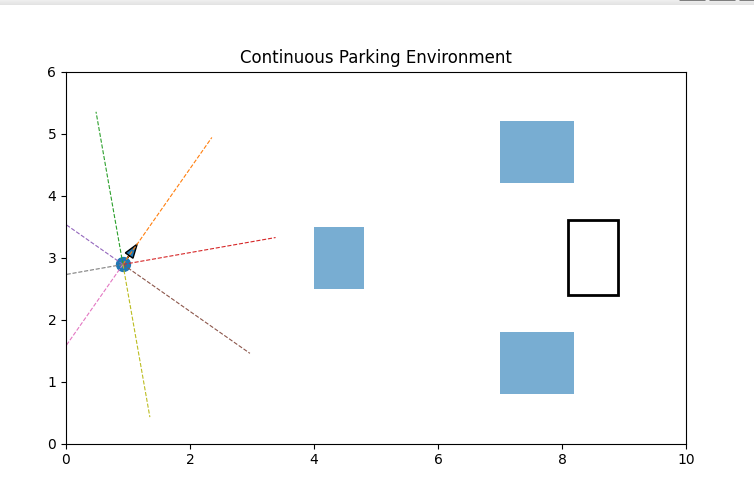

Usaremos el mismo entorno para 3 algoritmos distintos:
- DQN usara la observación continua directamente 
- Q-learning y SARSA no pueden usar directamente el vector continuo porque necesitarian una tabla (Q-table) muy grande entonces tendremos que discretizar y quedarnos con las variables mas importantes y las convertimos a intervalos 

primera posible versión del entorno:
- Mundo: 10 x 6 metros
- Vehículo: punto orientado
- Plaza: centro en (8.5, 3.0)
- Orientación objetivo: pi / 2
- Obstáculos: rectángulos sencillos
- Sensores: 8 rayos
- Máximo de pasos: 300
- Acciones: 7 discretas
- Observación: Box de 18 valores

Visualizando las primeras aproximaciones de nuestros algoritmos vemos que hay algunas cosas mas que debemos penalizar o premiar para que se desenvuelvan bien en el entorno:

## IMPLEMENTACION FINAL DE RECOMPENSA (continuous_parking_env.py)

1. **Penalización por paso**: se aplica una penalización constante de -0.08 en cada acción para favorecer trayectorias más cortas.

2. **Recompensa por progreso**: se recompensa la reducción de la distancia al centro de la plaza mediante el término 4.0 * delta_distance.

3. **Penalización por falta de progreso**: si el cambio de distancia es prácticamente nulo, se aplica una pequeña penalización adicional. Esto ayuda a evitar que el agente permanezca moviéndose sin avanzar realmente hacia el objetivo.

4. **Recompensa por orientación**: se premia la reducción del error angular. Esta recompensa se vuelve más importante cuando el vehículo está cerca de la plaza, porque en la fase final no basta con llegar, sino que también debe estar bien alineado.

5. **Penalización por riesgo**: si algún sensor detecta un obstáculo demasiado cerca, se aplica una penalización. Esta penalización fue endurecida en la versión final para evitar que el agente se acerque excesivamente a los vehículos aparcados.

6. **Penalización por oscilación**: se penalizan pares de acciones opuestas consecutivas, como avanzar y después retroceder. Esto se introdujo porque en versiones iniciales el agente podía quedarse atascado alternando acciones.

7. **Penalización o recompensa por frenar**: frenar lejos de la plaza se penaliza, pero frenar cerca y con buena orientación se recompensa.

8. **Penalización por colisión**: si el vehículo colisiona con un obstáculo o límite del entorno, recibe una penalización fuerte de -120.

9. **Bonus por centrado**: si el vehículo está cerca del centro de la plaza, recibe una recompensa adicional proporcional a la cercanía.

10. **Recompensa por aparcamiento correcto**: si cumple la condición de éxito, recibe una recompensa alta de +150.

- La condición de éxito no exige que el vehículo se sitúe exactamente en el centro geométrico de la plaza, sino que entre dentro de una tolerancia espacial. En concreto, se considera aparcado si la distancia al centro de la plaza es menor que 0.35, el error de orientación es menor que 0.25, la velocidad es prácticamente nula y la acción seleccionada es frenar. Esta tolerancia permite que el aprendizaje sea viable con algoritmos tabulares, aunque implica que el resultado no siempre sea un aparcamiento perfectamente centrado.

In [1]:
import sys
print(sys.executable)

/mnt/c/Users/laura/OneDrive/Escritorio/TERCERO 2º CUATRI CCDD/AAII/RL/parking_rl/.venv/bin/python


En principio para la discretizacion estamos reduciendo la observacion a las variables discretas importantes:
- distancia al objetivo
- ángulo hacia el objetivo
- error de orientación
- sensores principales
- velocidad

Eso seria la clave de la tabla Q[state][action]

## fase 4) ALGORITMO Q-LEARNING

La idea es 
- obs continua del entorno
- discretize_obs(obs)
- estado discreto tipo tupla como ya hemos comprobado al probar en tarn_random.py
- Q[state][action]

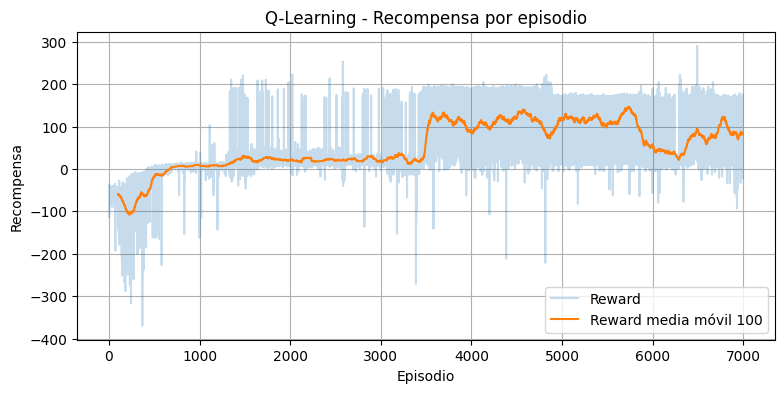

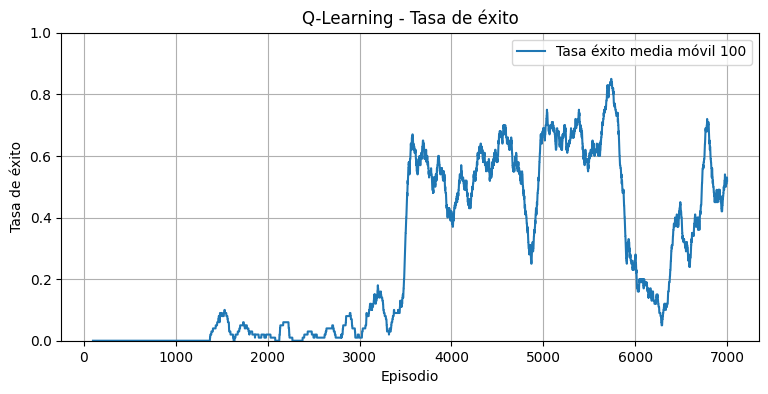

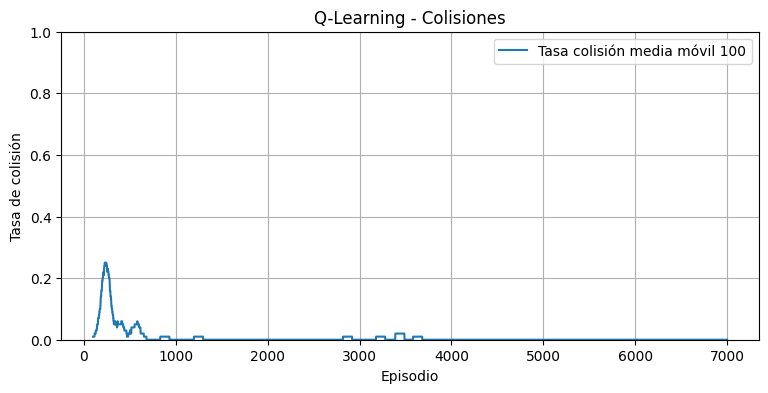

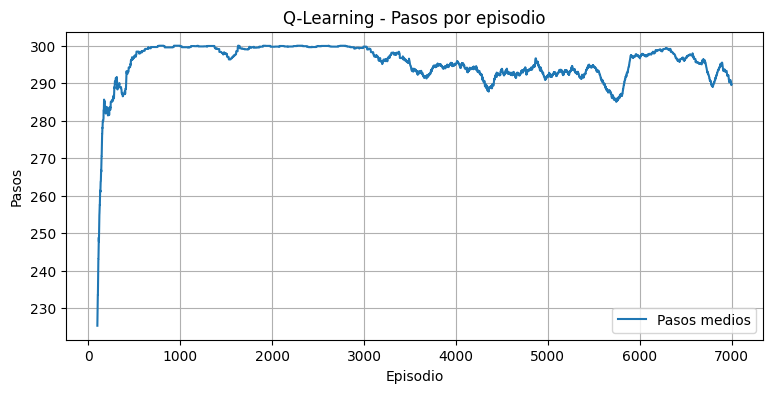

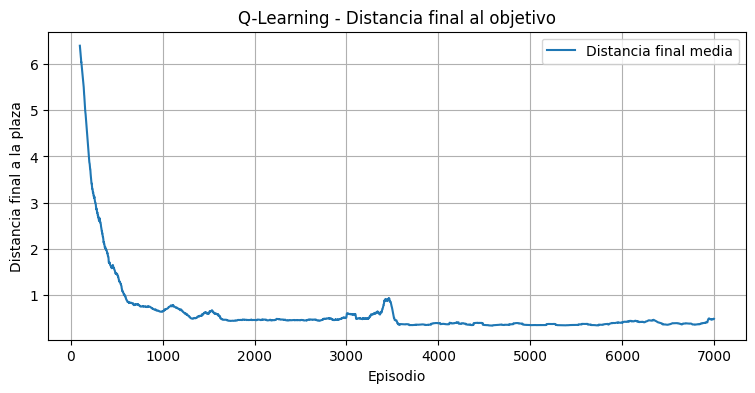

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/qlearning_results_v3.csv")

df["reward_ma"] = df["reward"].rolling(100).mean()
df["success_ma"] = df["success"].rolling(100).mean()
df["collision_ma"] = df["collision"].rolling(100).mean()
df["steps_ma"] = df["steps"].rolling(100).mean()
df["final_distance_ma"] = df["final_distance"].rolling(100).mean()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["reward"], alpha=0.25, label="Reward")
plt.plot(df["episode"], df["reward_ma"], label="Reward media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Q-Learning - Recompensa por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["success_ma"], label="Tasa éxito media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de éxito")
plt.title("Q-Learning - Tasa de éxito")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["collision_ma"], label="Tasa colisión media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de colisión")
plt.title("Q-Learning - Colisiones")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["steps_ma"], label="Pasos medios")
plt.xlabel("Episodio")
plt.ylabel("Pasos")
plt.title("Q-Learning - Pasos por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["final_distance_ma"], label="Distancia final media")
plt.xlabel("Episodio")
plt.ylabel("Distancia final a la plaza")
plt.title("Q-Learning - Distancia final al objetivo")
plt.legend()
plt.grid(True)
plt.show()

# fase 5) SARSA 

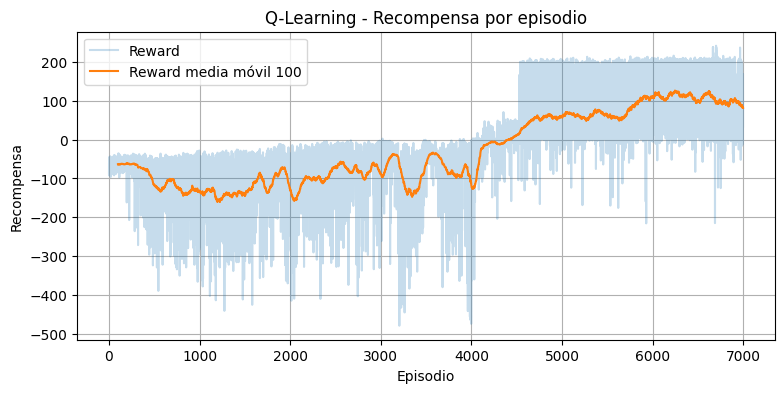

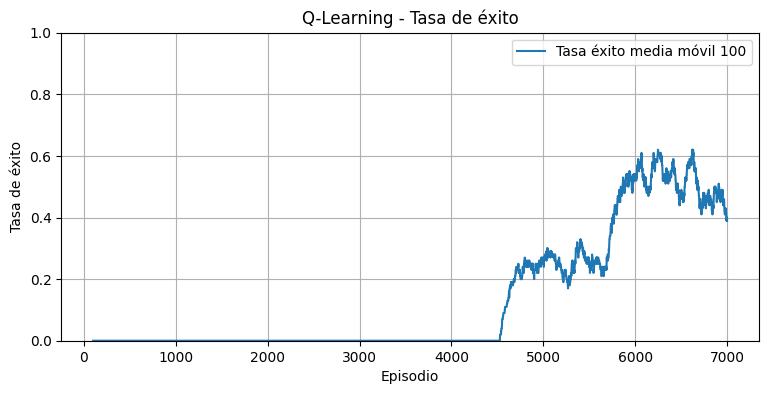

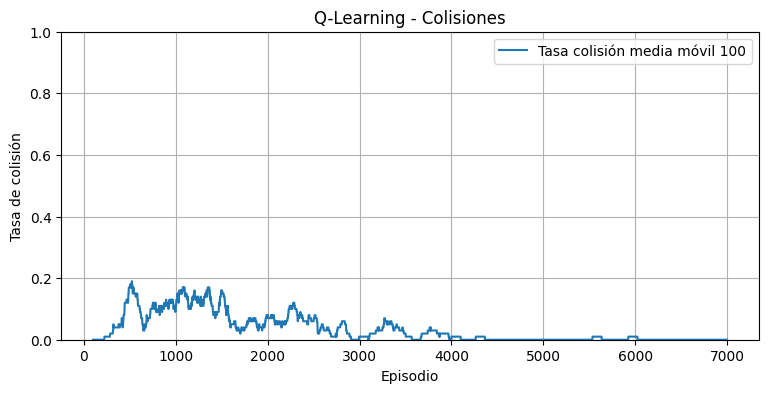

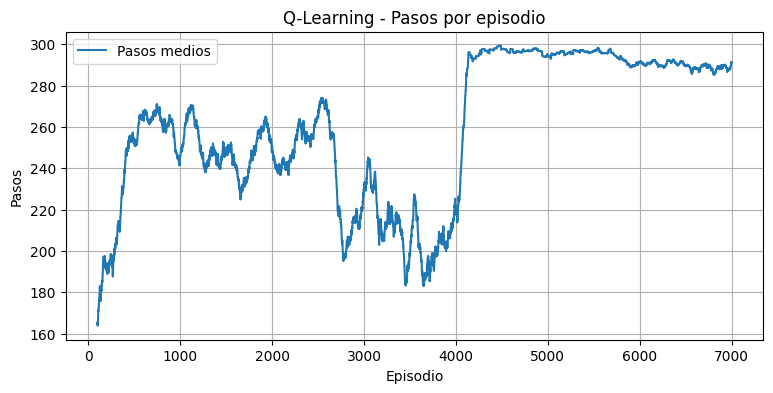

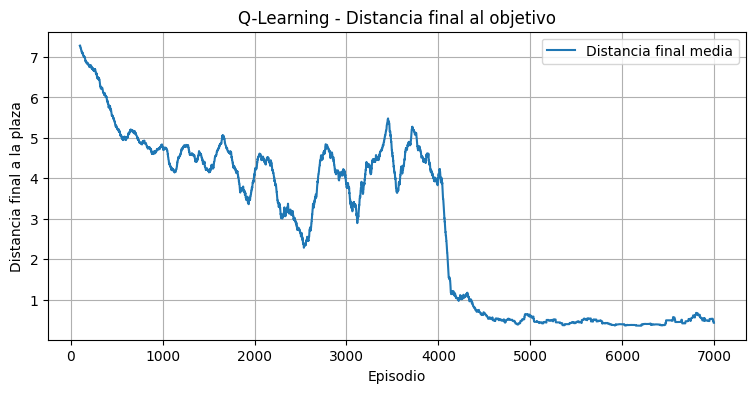

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/SARSA_v2.csv")

df["reward_ma"] = df["reward"].rolling(100).mean()
df["success_ma"] = df["success"].rolling(100).mean()
df["collision_ma"] = df["collision"].rolling(100).mean()
df["steps_ma"] = df["steps"].rolling(100).mean()
df["final_distance_ma"] = df["final_distance"].rolling(100).mean()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["reward"], alpha=0.25, label="Reward")
plt.plot(df["episode"], df["reward_ma"], label="Reward media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Q-Learning - Recompensa por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["success_ma"], label="Tasa éxito media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de éxito")
plt.title("Q-Learning - Tasa de éxito")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["collision_ma"], label="Tasa colisión media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de colisión")
plt.title("Q-Learning - Colisiones")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["steps_ma"], label="Pasos medios")
plt.xlabel("Episodio")
plt.ylabel("Pasos")
plt.title("Q-Learning - Pasos por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["final_distance_ma"], label="Distancia final media")
plt.xlabel("Episodio")
plt.ylabel("Distancia final a la plaza")
plt.title("Q-Learning - Distancia final al objetivo")
plt.legend()
plt.grid(True)
plt.show()

## Comparacion sarsa y q-learning

En ambos algoritmos se observa que el vehículo no siempre termina exactamente en el centro de la plaza, sino dentro de una tolerancia espacial y angular. Esto se debe a que la condición de éxito se define mediante umbrales de distancia y orientación, no como una igualdad exacta. Además, al usar métodos tabulares sobre una discretización del estado continuo, la política aprendida pierde precisión.


In [10]:
def resumen_final(df, nombre, n=500):
    tail = df.tail(n)
    return {
        "algoritmo": nombre,
        "reward_medio": tail["reward"].mean(),
        "success_rate": tail["success"].mean(),
        "collision_rate": tail["collision"].mean(),
        "steps_medio": tail["steps"].mean(),
        "final_distance_media": tail["final_distance"].mean(),
    }
df_q_v2 = pd.read_csv("results/qlearning_results_v2.csv")
df_q_v3 = pd.read_csv("results/qlearning_results_v3.csv")
df_sarsa = pd.read_csv("results/SARSA_v2.csv")
resumen = pd.DataFrame([
    resumen_final(df_q_v2, "Q-Learning v2"),
    resumen_final(df_q_v3, "Q-Learning v3"),
    resumen_final(df_sarsa, "SARSA"),
])

resumen

,algoritmo,reward_medio,success_rate,collision_rate,steps_medio,final_distance_media
0,Q-Learning v2,181.440798,0.948,0.0,253.174,0.350782
1,Q-Learning v3,84.241179,0.462,0.0,293.368,0.407720
2,SARSA,98.550934,0.474,0.0,288.868,0.504246


Las métricas agregadas se calculan sobre los últimos 500 episodios del entrenamiento, mientras que las visualizaciones corresponden a ejecuciones greedy concretas de la política aprendida. Por ello puede ocurrir que una política aparque correctamente en evaluación visual aunque su tasa media de éxito no sea cercana a 1.

Q-Learning v2 obtiene los mejores valores agregados de recompensa y tasa de éxito, pero no se toma como versión final porque fue entrenado bajo una configuración menos exigente (previa a modificar la recompensa del entorno). Q-Learning v3 representa mejor el comportamiento del agente en el entorno definitivo. Aunque sus métricas medias son inferiores a v2, consigue una política greedy capaz de aparcar correctamente sin colisiones Este fue implementado como un experimento inicial.

Comparando Q-Learning v3 y SARSA, ambos algoritmos resuelven la tarea en evaluación visual. SARSA tiende a dirigirse de forma más directa hacia la plaza, pero una vez cerca realiza más movimientos de ajuste, especialmente de avance y retroceso, lo que retrasa la finalización del episodio. Q-Learning, en cambio, realiza una trayectoria inicial menos directa, pero cuando alcanza la entrada de la plaza ejecuta la maniobra final de forma más limpia y termina en menos pasos en la evaluación visual.

En conclusión, los resultados muestran que ambos algoritmos tabulares son capaces de aprender una política válida para el entorno de aparcamiento. La diferencia entre ambos comportamientos puede relacionarse con la naturaleza de los algoritmos. Q-Learning, al ser off-policy, actualiza sus valores usando la mejor acción estimada en el siguiente estado, lo que puede favorecer decisiones más orientadas al objetivo final. SARSA, al ser on-policy, aprende teniendo en cuenta la acción realmente seleccionada por la política exploratoria, lo que puede hacerlo más sensible a las maniobras de ajuste y a la exploración residual.

No obstante, las políticas obtenidas no son óptimas en sentido estricto. El entorno es continuo, pero Q-Learning y SARSA trabajan sobre una discretización del estado, lo que limita la precisión de la política aprendida. Por ello, es normal observar trayectorias no perfectamente suaves, movimientos de corrección y aparcamientos que no quedan exactamente en el centro de la plaza. Aun así, el objetivo principal se cumple: ambos agentes aprenden a aparcar sin colisionar en el entorno simulado.

## Deep Q-Learning

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_results(nombre, window=100):
    """Visualiza los resultados de entrenamiento de un algoritmo.
    
    nombre: nombre del algoritmo, debe coincidir con el CSV (ej: 'dqn', 'double_dqn', 'dueling_dqn')
    window: tamaño de la ventana para la media móvil
    """
    df = pd.read_csv(f"results/{nombre}_results.csv")

    df["reward_ma"]         = df["reward"].rolling(window).mean()
    df["success_ma"]        = df["success"].rolling(window).mean()
    df["collision_ma"]      = df["collision"].rolling(window).mean()
    df["steps_ma"]          = df["steps"].rolling(window).mean()
    df["final_distance_ma"] = df["final_distance"].rolling(window).mean()

    titulo = nombre.replace("_", " ").upper()

    metricas = [
        ("reward",         "Recompensa",              "Recompensa por episodio", None),
        ("success",        "Tasa de éxito",           "Tasa de éxito",           (0, 1)),
        ("collision",      "Tasa de colisión",        "Colisiones",              (0, 1)),
        ("steps",          "Pasos",                   "Pasos por episodio",      None),
        ("final_distance", "Distancia final a plaza", "Distancia final al objetivo", None),
    ]

    for col, ylabel, subtitulo, ylim in metricas:
        plt.figure(figsize=(9, 4))
        if col == "reward":
            plt.plot(df["episode"], df[col], alpha=0.25, label=ylabel)
        plt.plot(df["episode"], df[f"{col}_ma"], label=f"{ylabel} media móvil {window}")
        plt.xlabel("Episodio")
        plt.ylabel(ylabel)
        plt.title(f"{titulo} - {subtitulo}")
        if ylim:
            plt.ylim(*ylim)
        plt.legend()
        plt.grid(True)
        plt.show()